#Text - HuggingFace Jigsaw Toxic Comment Classification

In [ ]:
!pip install datasets scikit-learn matplotlib seaborn pandas transformers

##Problem framing
This study aims to train a binary classification model that identifies toxic comments. This serves the global purpose of better content moderation online.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import random

In [ ]:
dataset = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/68.8M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/60.4M [00:00<?, ?B/s]

test_labels.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/306328 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
    test: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 306328
    })
})

The Hugginface dataset is split into train and test data. The official test split does not contain labels, so it cannot be used for supervised training or evaluation.
Therefore, I used the labeled train split and created my own stratified train-test split to evaluate the model while preserving reproducibility and preventing data leakage.

In [ ]:
df = pd.DataFrame(dataset['train'])
df = df[['comment_text', 'toxic']]

print(df.shape)
df.head()

(159571, 2)


,comment_text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


In [ ]:
#target class distribution

print(df['toxic'].value_counts())
df["toxic"].value_counts(normalize=True) * 100

toxic
0    144277
1     15294
Name: count, dtype: int64


,proportion
toxic,
0,90.415552
1,9.584448


Data is heavily imbalanced, which is normal for a case like this.

**Performance metrics**: We want to reduce harmful content but avoid censoring too much. Therefore, we prioritize **maximizing recall** for the toxic class while maintaining a **high precision threshold (≥ 0.90)** to prevent excessive false positives.

##Data cleaning / Preparation

In [ ]:
# Check for missing values
print(df.isnull().sum())

comment_text    0
toxic           0
dtype: int64


In [ ]:
#basic cleaning
df['comment_text'] = df['comment_text'].str.lower().str.strip()

In [ ]:
#removing links, addresses, ponctuation, extra spaces
import re

def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
df["comment_text"] = df["comment_text"].apply(clean_text)

##Exploratory Data Analysis

###Class Distribution

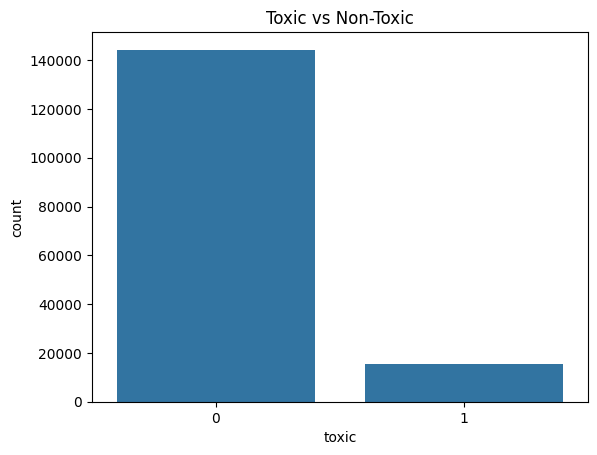

In [ ]:
sns.countplot(x='toxic', data=df)
plt.title("Toxic vs Non-Toxic")
plt.show()

This re-affirms the high imbalance of the dataset, with most of the comments being "non toxic". This affects model choice and evaluation metrics. As we established earlier, accuracy alone is misleading, so we focus on maximising recall at a precision target for the toxic class.  
 Imbalanced classes can also motivate resampling strategies or using class weights; in this project, we will use class_weight='balanced' in Logistic Regression or Random Forest to ensure the minority class receives sufficient importance during training.

###Comment length distribution

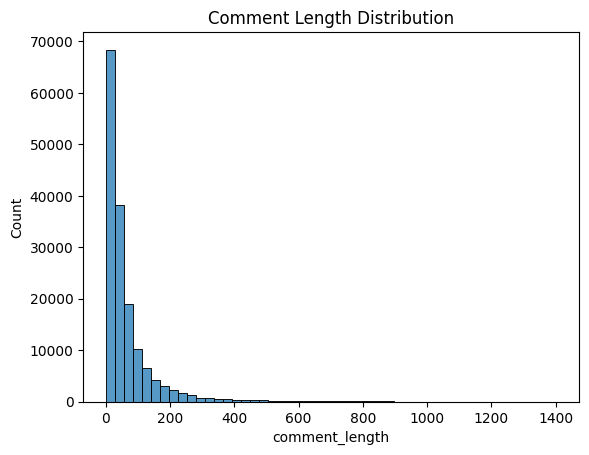

In [ ]:
df['comment_length'] = df['comment_text'].str.split().apply(len)
sns.histplot(df['comment_length'], bins=50)
plt.title("Comment Length Distribution")
plt.show()

Most comments are short or medium length as no comment is longer than 850 words. According to the graph, some comments might be empty. This sparsity suggests that linear models on TF-IDF vectors are appropriate. Extremely short or empty comments may bias the model toward predicting the majority class.

In [ ]:
#seeing empty comments
empty_count = (df['comment_text'].str.strip() == "").sum()
print(f"Number of empty comments: {empty_count}")

Number of empty comments: 14


In [ ]:
# Remove empty or whitespace-only comments
df = df[df['comment_text'].str.strip() != ""]

###Word frequency

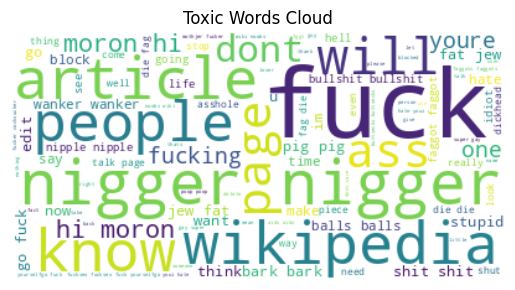

In [ ]:
from wordcloud import WordCloud

toxic_text = " ".join(df[df['toxic']==1]['comment_text'].values)
non_toxic_text = " ".join(df[df['toxic']==0]['comment_text'].values)

wc = WordCloud(max_words=100, background_color="white").generate(toxic_text)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Toxic Words Cloud")
plt.show()

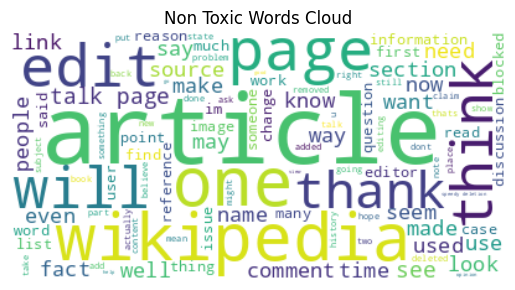

In [ ]:
wc2 = WordCloud(max_words=100, background_color="white").generate(non_toxic_text)
plt.imshow(wc2, interpolation="bilinear")
plt.axis("off")
plt.title("Non Toxic Words Cloud")
plt.show()

Toxic comments primarily contain insults and anti-racial contents.

##Baseline Model

In [ ]:
#splitting the dataset and vectorization
X = df['comment_text']
y = df['toxic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert text to features
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold

scoring = ["precision","recall"]

dummy = DummyClassifier(strategy='most_frequent', random_state=42)

#training in k iterations
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(dummy, X_train_vec, y_train, cv=cv, scoring=scoring)

scores = pd.DataFrame(cv_results)
scores.round(4)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

,fit_time,score_time,test_precision,test_recall
0,0.1136,0.0707,0.0,0.0
1,0.1069,0.0539,0.0,0.0
2,0.0956,0.0340,0.0,0.0
3,0.0355,0.0192,0.0,0.0
4,0.0254,0.0167,0.0,0.0


In [ ]:
#let's test the DummyClassifier model on test data
from sklearn.metrics import classification_report, confusion_matrix

dummy.fit(X_train_vec, y_train)
test_pred = dummy.predict(X_test_vec)
print(classification_report(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95     28853
           1       0.00      0.00      0.00      3059

    accuracy                           0.90     31912
   macro avg       0.45      0.50      0.47     31912
weighted avg       0.82      0.90      0.86     31912

[[28853     0]
 [ 3059     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


As predicted, the dummy classifier did a great job identifying the dominant class but was completely unable to identify any of the class 1.

##Model Improvement and Experimental design

We chose **Logistic Regression**. It is often chosen for TF-IDF, which creates sparse, high-dimensional feature vectors. Logistic Regression handles them efficiently and provide interpretable coefficients for feature importance.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression


params = {
    "tfidf__max_features": [3000, 5000, 8000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "model__C": [0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

In [ ]:
#pipeline creation
from sklearn.pipeline import Pipeline


pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LogisticRegression(random_state=42))
])

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    scoring={"precision": "precision", "recall": "recall", "f1":"f1"},
    refit="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Params: {'model__C': 10, 'model__class_weight': None, 'tfidf__max_features': 8000, 'tfidf__ngram_range': (1, 1)}
Best CV Score: 0.7530900689834278


In [ ]:
#test model by predicting target for X_test
y_pred = grid.best_estimator_.predict(X_test)

#performance report
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     28853
           1       0.88      0.70      0.78      3059

    accuracy                           0.96     31912
   macro avg       0.93      0.84      0.88     31912
weighted avg       0.96      0.96      0.96     31912

[[28569   284]
 [  925  2134]]


Analysis:
The model performs way better than the baseline showing that it is able to capture relationships. At a threshold of 0.5, we are able to reach a recall of 0.70 with a precision of 0.88, near the precision target that we set.
We went from a model that couldn't predict the Toxic class at all to a 0.96 accuracy model with a recall of 0.70

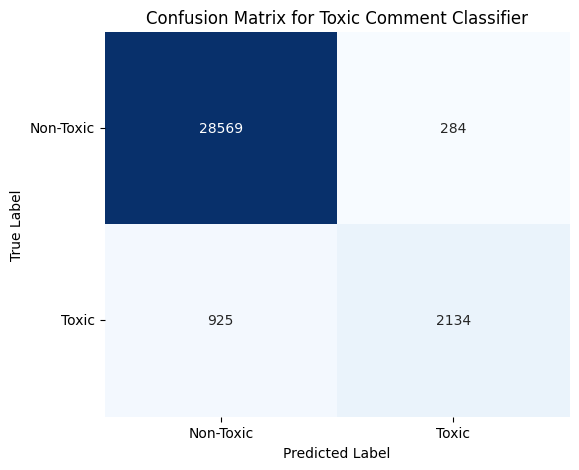

In [ ]:
#let's visualise the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Toxic Comment Classifier")
plt.xticks([0.5, 1.5], ["Non-Toxic", "Toxic"])
plt.yticks([0.5, 1.5], ["Non-Toxic", "Toxic"], rotation=0)
plt.show()

Let's see the difference in performance at different probability tresholds

In [ ]:
y_probs = grid.best_estimator_.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

#we will test different threshold to see how the metrics evolve
thresholds = [0.3, 0.5, 0.7]

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    print(f"\nThreshold: {t}")
    print("Precision:", precision_score(y_test, y_pred_t))
    print("Recall:", recall_score(y_test, y_pred_t))
    print("F1:", f1_score(y_test, y_pred_t))


Threshold: 0.3
Precision: 0.8063750423872499
Recall: 0.7773782281791435
F1: 0.7916111850865513

Threshold: 0.5
Precision: 0.8825475599669148
Recall: 0.6976135992154299
F1: 0.7792587182764287

Threshold: 0.7
Precision: 0.9356581532416502
Recall: 0.6227525335076822
F1: 0.7477919528949951


From that experiment, we can see that lowering the threshold to 0.3 increases recall but decreases precision: more toxic comments are detected at the cost of more false positives. Increasing the threshold to 0.7 improves precision but reduces recall.
This demonstrates the precision–recall trade-off in imbalanced text classification.

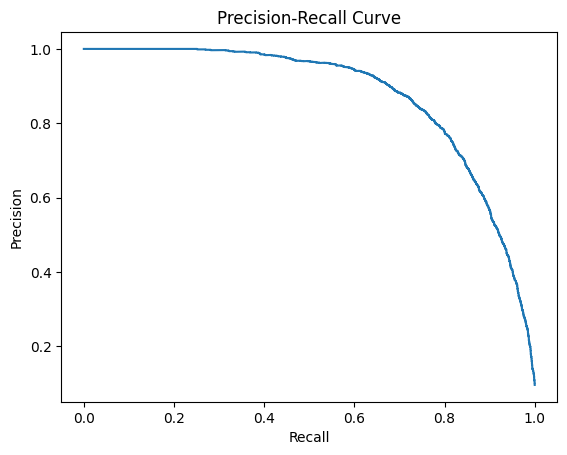

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

This graph suggests that with this model, we can at best get a 0.80 recall with a near 0.80 precision, symbolizing once again the trade-offs that we have to make.

##Interpretability

In [ ]:
best_model = grid.best_estimator_

In [ ]:
vectorizer = best_model.named_steps["tfidf"]
lr = best_model.named_steps["model"]

feature_names = vectorizer.get_feature_names_out()
coefs = lr.coef_[0]

#getting the words that contributed more and less
top_negative = np.argsort(coefs)[-10:]
top_positive = np.argsort(coefs)[:10]

print("Top words contributing to toxicity:")
print(feature_names[top_negative])

print("Top words contributing to non-toxicity:")
print(feature_names[top_positive])

Top words contributing to toxicity:
['ass' 'bitch' 'asshole' 'suck' 'stupid' 'bullshit' 'idiot' 'shit'
 'fucking' 'fuck']
Top words contributing to non-toxicity:
['thank' 'redirect' 'thanks' 'sorry' 'cheers' 'appreciate' 'agree'
 'wikiproject' 'interested' 'may']


As we could see in the word cloud earlier, most toxicity related words are insults or swearing while non-toxicity related words are polite words, excuses and words of appreciation

#Report

##Introduction
Globalization has brought the world together. With the advent of social media and various online communication tools, chatting with someone on the other side of the world is no longer a myth: it's a reality. To ensure a healthy online space for everyone, it is important to moderate the interactions and discussions that take place online. To this end, scientists have been working on detecting problematic comments, which are then deleted to ensure the well-being of all. In this notebook, we will train a supervised comment classification model.

##Dataset Description
*Number features, class imbalance, comment length stats.*  
This dataset originally contains eight features but we are currently focusing on only two which are :


*   comment_text: the actual comment
*   toxic: a label that indicates whether the comment is appropriate or not.

The dataset presents a heavily imbalance of approximately 90/10 with non-toxic comments dominating, as it is common for that type of situation. Comments are mostly short, within the range of 0-200 words but can be really long (800 words)

##Safety/Ethics Note
This study uses the Jigsaw Toxic Comment dataset, which contains comments that are potentially offensive. To ensure safety and respect, no actual comment was quoted during this study.   
The analyses are all based on aggregated statistical values and the dataset is used solely for educational purposes. This work also considers the impact of model decisions on content moderation by highlighting the importance of precision-recall trade-offs in identifying harmful content.

##Methodology

A reproducibe ML pipeline was built to process the dataset and train the model. The first preprocessing step was the "cleaning" of the text: remowing links, punctuation, and empty comments. We used TF-IDF vectorization to convert text into numerical features/vectors. After training a basic Dummy classifier model, a Logistic Regression model was trained based on the result of hyperparameter tuning by GridSearchCV. The parameters in the search space included C values and n-gram. Cross-validation ensured model generalization and avoided data leakage. For the model interpretation, feature coefficients were computed.
Finally, the performance of the model was assessed by the maximisation of recall at a precision target (>0.90) as it is very important to be able to catch all problematic comments, while maintaining precision. We couldn't reach that target as threshold analysis performed on predicted probabilities highlighted the precision-recall trade-offs involved in our case.

##Results

**Baseline Performance**  
DummyClassifier metrics (random baseline, stratified) on the test set (class 1):  
- Precision: 1.00  
- Recall: 0.00  
- F1-score: 0.00

**Model Performance**  
Logistic Regression with TF-IDF features outperforms the baseline (class 1):  
- Precision (threshold 0.5): 0.88  
- Recall (threshold 0.5): 0.70  
- F1-score: 0.78

**Confusion Matrix**  
See Figure *"Confusion Matrix for Toxic Comment Classifier"* above. The model correctly identifies the majority of toxic comments (true positives) but some are misclassified (false negatives). Most non-toxic comments are correctly identified (true negatives).  

**Threshold Analysis**  
Precision and recall at different thresholds illustrate the trade-off involved in toxic comment detection:  

| Threshold | Precision | Recall | F1-score |
|-----------|----------|--------|----------|
| 0.3       | 0.806 | 0.78 | 0.79 |
| 0.5       | 0.88 | 0.70 | 0.78 |
| 0.7       | 0.94 | 0.62 | 0.75 |

Lowering the threshold increases recall but reduces precision; increasing the threshold improves precision at the cost of recall.

**Top Features / Interpretability**  
Top weighted words contributing to toxicity and non-toxicity:  
- Toxic: ass, bitch, asshole, suck, stupid, bullshit, idiot, shit,
 fucking, fuck  
- Non-toxic: thank, redirect, thanks, sorry, cheers, appreciate, agree,wikiproject, interested, may

These features provide an insight into what the model considers toxic language.

##Conclusions

- The logistic regression model significantly outperforms the baseline across all key metrics (Precision, Recall, F1) on class 1.
- By analysis the decision threshold, we were enable to evaluate the trade-off between recall and precision: lowering the decision threshold increases recall at the cost of precision, so finding a balance is important.
- The probability threshold is to be selected carefully to balance false positives and false negatives in content moderation.